In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib

## Read in data

In [2]:
df = pd.read_csv('../data/part_b/part_b_results.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.head()

(3600, 10)


,puzzle_id,strategy,condition,size,word_count,avg_word_length,cells_examined,execution_time,words_found,total_words
0,B_short_0000,Brute Force,short,30,16,5.0,11615,0.001704,16,16
1,B_short_0000,Ordered Search,short,30,16,5.0,11615,0.001836,16,16
2,B_short_0000,Uncommon Letter Search,short,30,16,5.0,10268,0.001281,16,16
3,B_short_0000,Random Sample (attempts=5000),short,30,16,5.0,11822,0.002460,16,16
4,B_short_0000,Patch Search,short,30,16,5.0,15535,0.002674,16,16


In [3]:
df.describe()

,size,word_count,avg_word_length,cells_examined,execution_time,words_found,total_words
count,3600.0,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000
mean,30.0,19.573333,6.498837,12410.825000,0.002236,19.573333,19.573333
std,0.0,2.823739,1.226767,2746.978313,0.000910,2.823739,2.823739
min,30.0,15.000000,5.000000,3555.000000,0.000683,15.000000,15.000000
25%,30.0,17.000000,5.000000,10584.750000,0.001550,17.000000,17.000000
50%,30.0,20.000000,6.500000,12241.000000,0.002008,20.000000,20.000000
75%,30.0,22.000000,8.000000,13969.500000,0.002796,22.000000,22.000000
max,30.0,24.000000,8.000000,50589.000000,0.010461,24.000000,24.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   puzzle_id        3600 non-null   object 
 1   strategy         3600 non-null   object 
 2   condition        3600 non-null   object 
 3   size             3600 non-null   int64  
 4   word_count       3600 non-null   int64  
 5   avg_word_length  3600 non-null   float64
 6   cells_examined   3600 non-null   int64  
 7   execution_time   3600 non-null   float64
 8   words_found      3600 non-null   int64  
 9   total_words      3600 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 281.4+ KB


# Time analysis

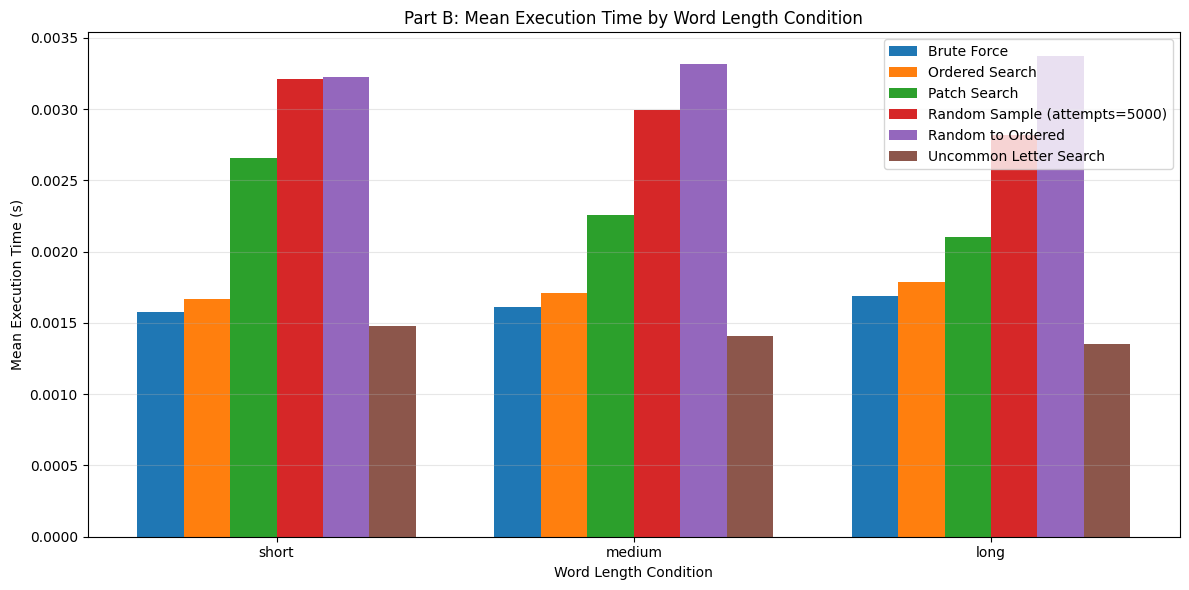

In [5]:
mean_time = df.groupby(['strategy', 'condition'])['execution_time'].mean().reset_index()

# Fix condition order
condition_order = ['short', 'medium', 'long']
mean_time['condition'] = pd.Categorical(mean_time['condition'], categories=condition_order, ordered=True)
mean_time = mean_time.sort_values(['condition', 'strategy'])

fig, ax = plt.subplots(figsize=(12, 6))

strategies = mean_time['strategy'].unique()
x = range(len(condition_order))
width = 0.13
offsets = [i * width - (len(strategies) - 1) * width / 2 for i in range(len(strategies))]

for i, strategy in enumerate(sorted(strategies)):
    group = mean_time[mean_time['strategy'] == strategy]
    group = group.set_index('condition').reindex(condition_order)
    ax.bar([xi + offsets[i] for xi in x], group['execution_time'], width=width, label=strategy)

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_title('Part B: Mean Execution Time by Word Length Condition')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

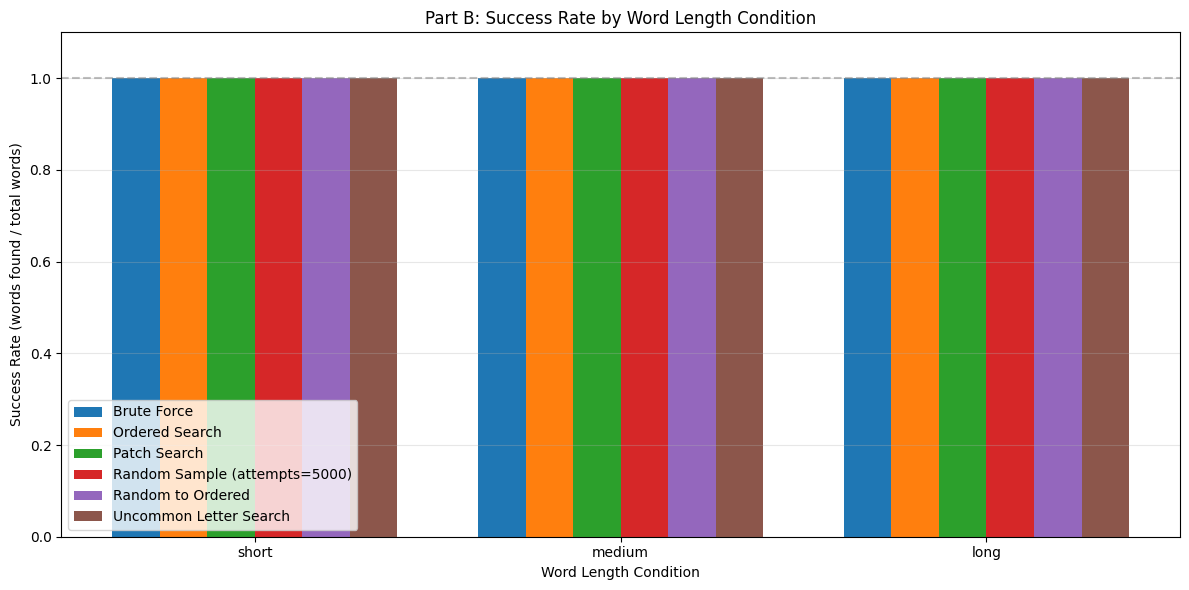

In [6]:
success = df.groupby(['strategy', 'condition']).agg(
    words_found=('words_found', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
success['success_rate'] = success['words_found'] / success['total_words']

condition_order = ['short', 'medium', 'long']
success['condition'] = pd.Categorical(success['condition'], categories=condition_order, ordered=True)
success = success.sort_values(['condition', 'strategy'])

fig, ax = plt.subplots(figsize=(12, 6))
strategies = sorted(success['strategy'].unique())
x = range(len(condition_order))
width = 0.13
offsets = [i * width - (len(strategies) - 1) * width / 2 for i in range(len(strategies))]

for i, strategy in enumerate(strategies):
    group = success[success['strategy'] == strategy].set_index('condition').reindex(condition_order)
    ax.bar([xi + offsets[i] for xi in x], group['success_rate'], width=width, label=strategy)

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Success Rate (words found / total words)')
ax.set_title('Part B: Success Rate by Word Length Condition')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

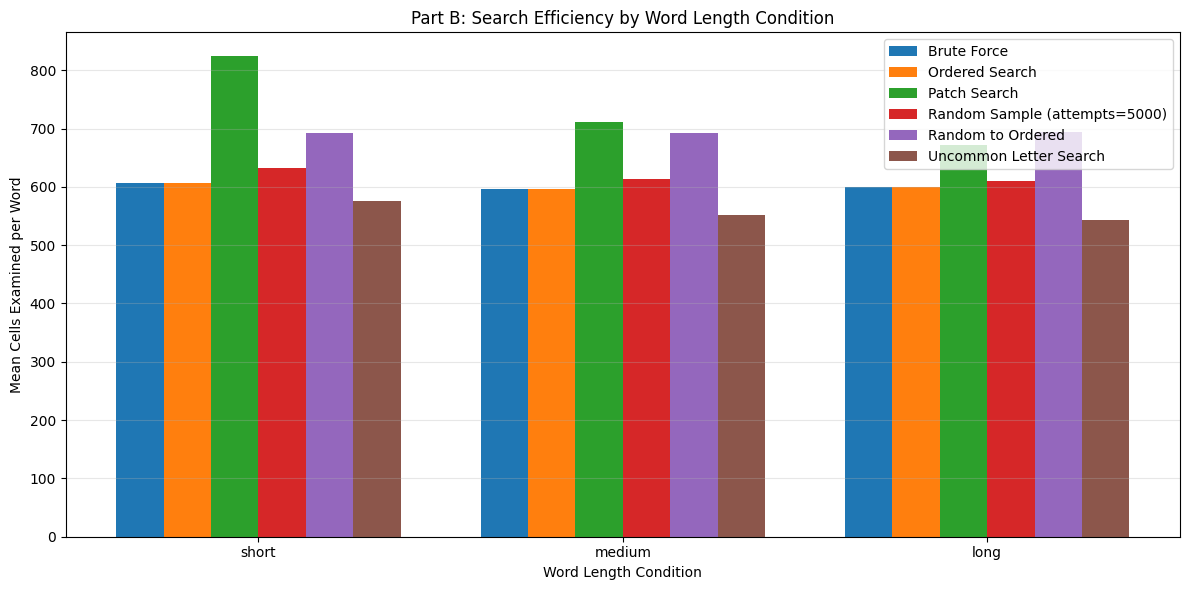

In [7]:
eff = df.groupby(['strategy', 'condition']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
eff['cells_per_word'] = eff['cells_examined'] / eff['total_words']
eff['condition'] = pd.Categorical(eff['condition'], categories=condition_order, ordered=True)
eff = eff.sort_values(['condition', 'strategy'])

fig, ax = plt.subplots(figsize=(12, 6))
for i, strategy in enumerate(strategies):
    group = eff[eff['strategy'] == strategy].set_index('condition').reindex(condition_order)
    ax.bar([xi + offsets[i] for xi in x], group['cells_per_word'], width=width, label=strategy)

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Mean Cells Examined per Word')
ax.set_title('Part B: Search Efficiency by Word Length Condition')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

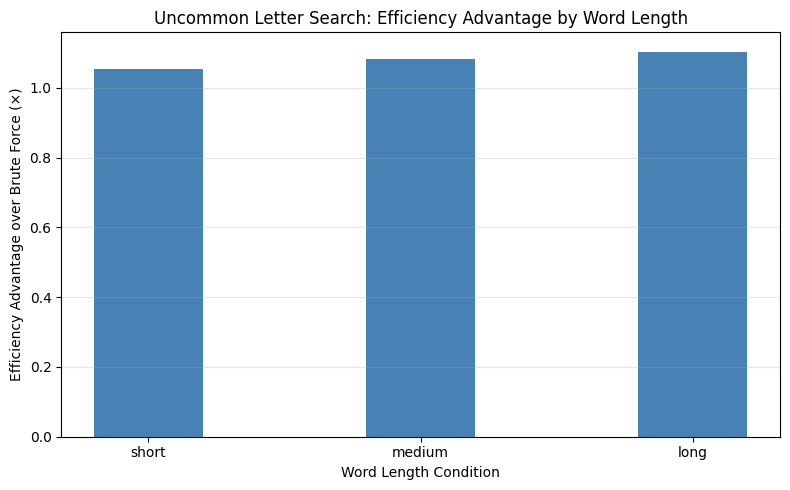

In [8]:
eff_uls = eff.copy()
bf_cells = eff_uls[eff_uls['strategy'] == 'Brute Force'][['condition', 'cells_per_word']].rename(columns={'cells_per_word': 'bf_cells'})
eff_uls = eff_uls.merge(bf_cells, on='condition')
eff_uls['advantage_ratio'] = eff_uls['bf_cells'] / eff_uls['cells_per_word']
eff_uls = eff_uls[eff_uls['strategy'] == 'Uncommon Letter Search'].set_index('condition').reindex(condition_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(condition_order, eff_uls['advantage_ratio'], color='steelblue', width=0.4)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Efficiency Advantage over Brute Force (×)')
ax.set_title('Uncommon Letter Search: Efficiency Advantage by Word Length')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Generate Formatted plots for report

In [9]:
# ── IEEE formatting ──────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'lines.linewidth':   1.8,
    'lines.markersize':  4,
    'axes.linewidth':    0.8,
    'grid.linewidth':    0.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    # 'text.usetex':     True,   # uncomment if LaTeX is installed
})

IEEE_1COL = 3.5    # single-column width (inches)
IEEE_2COL = 7.16   # full-width (both columns)

# Wong (2011) colorblind-safe palette
COLORS = {
    'Brute Force':                   '#000000',
    'Ordered Search':                '#0072B2',
    'Patch Search':                  '#009E73',
    'Random Sample (attempts=5000)': '#D55E00',
    'Random to Ordered':             '#CC79A7',
    'Uncommon Letter Search':        '#E69F00',
}
MARKERS = {
    'Brute Force':                   'o',
    'Ordered Search':                's',
    'Patch Search':                  '^',
    'Random Sample (attempts=5000)': 'D',
    'Random to Ordered':             'v',
    'Uncommon Letter Search':        '*',
}

os.makedirs('plots', exist_ok=True)

In [10]:
strategies_sorted = sorted(COLORS.keys())

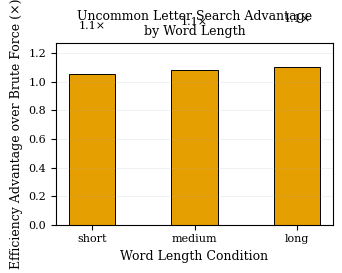

Saved fig3_uls_word_length.pdf


In [11]:
condition_order = ['short', 'medium', 'long']
eff_b = df.groupby(['strategy', 'condition']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
eff_b['cells_per_word'] = eff_b['cells_examined'] / eff_b['total_words']

bf_b = eff_b[eff_b['strategy'] == 'Brute Force'][['condition', 'cells_per_word']].rename(columns={'cells_per_word': 'bf_cells'})
eff_b = eff_b.merge(bf_b, on='condition')
eff_b['advantage'] = eff_b['bf_cells'] / eff_b['cells_per_word']
uls = eff_b[eff_b['strategy'] == 'Uncommon Letter Search'].set_index('condition').reindex(condition_order)

fig, ax = plt.subplots(figsize=(IEEE_1COL, 2.8))
bars = ax.bar(condition_order, uls['advantage'],
              color=COLORS['Uncommon Letter Search'], width=0.45, edgecolor='black', linewidth=0.7)

# value labels on bars
for bar, val in zip(bars, uls['advantage']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}×', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Efficiency Advantage over Brute Force (×)')
ax.set_title('Uncommon Letter Search Advantage\nby Word Length')
ax.set_ylim(0, uls['advantage'].max() * 1.15)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('../plots/fig3_uls_word_length.pdf')
plt.show()
print("Saved fig3_uls_word_length.pdf")

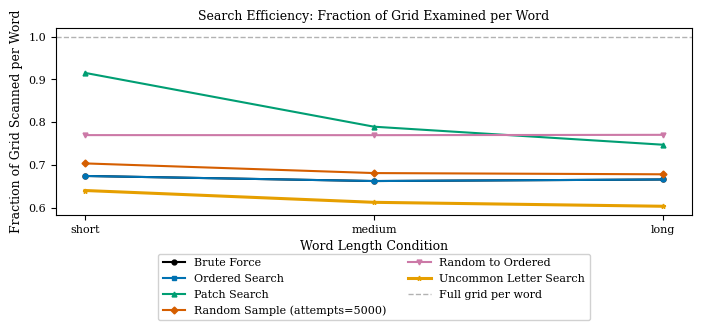

Saved figB_efficiency.pdf


In [12]:
# --- IEEE 2-column publication plot: Fraction of Grid Scanned per Word (with correct x-axis alignment) ---
import matplotlib
matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'lines.linewidth':   1.8,
    'lines.markersize':  4,
    'axes.linewidth':    0.8,
    'grid.linewidth':    0.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    # 'text.usetex':     True,   # uncomment if LaTeX is installed
})
IEEE_2COL = 7.16
COLORS = {
    'Brute Force':                   '#000000',
    'Ordered Search':                '#0072B2',
    'Patch Search':                  '#009E73',
    'Random Sample (attempts=5000)': '#D55E00',
    'Random to Ordered':             '#CC79A7',
    'Uncommon Letter Search':        '#E69F00',
}
MARKERS = {
    'Brute Force':                   'o',
    'Ordered Search':                's',
    'Patch Search':                  '^',
    'Random Sample (attempts=5000)': 'D',
    'Random to Ordered':             'v',
    'Uncommon Letter Search':        '*',
}
strategies_sorted = sorted(COLORS.keys())
condition_order = ['short', 'medium', 'long']

# --- Compute fraction of grid scanned per word for each strategy/condition ---
eff = df.groupby(['strategy', 'condition']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean'),
    size=('size', 'mean')
).reset_index()
eff['fraction_per_word'] = (eff['cells_examined'] / eff['total_words']) / (eff['size'] ** 2)
eff['condition'] = pd.Categorical(eff['condition'], categories=condition_order, ordered=True)
eff = eff.sort_values(['strategy', 'condition'])

import os
os.makedirs('plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(IEEE_2COL, 2.8))
for strategy in strategies_sorted:
    group = eff[eff['strategy'] == strategy].set_index('condition').reindex(condition_order)
    lw = 2.2 if strategy == 'Uncommon Letter Search' else 1.5
    ax.plot(condition_order, group['fraction_per_word'],
            color=COLORS[strategy], marker=MARKERS[strategy],
            linewidth=lw, markersize=3.5, label=strategy)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.6, label='Full grid per word')
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Fraction of Grid Scanned per Word')
ax.set_title('Search Efficiency: Fraction of Grid Examined per Word')
#ax.set_ylim(0, 1.05)
ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.18), framealpha=0.9)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('../plots/figB_efficiency.pdf')
plt.show()
print("Saved figB_efficiency.pdf")


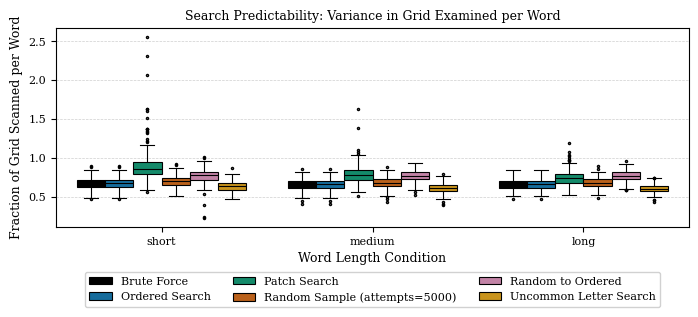

Saved figB_predictability_spread.pdf


In [15]:
# --- IEEE 2-column publication plot: Predictability Spread (Boxplot) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib
import os

matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'lines.linewidth':   1.8,
    'lines.markersize':  4,
    'axes.linewidth':    0.8,
    'grid.linewidth':    0.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})
IEEE_2COL = 7.16
COLORS = {
    'Brute Force':                   '#000000',
    'Ordered Search':                '#0072B2',
    'Patch Search':                  '#009E73',
    'Random Sample (attempts=5000)': '#D55E00',
    'Random to Ordered':             '#CC79A7',
    'Uncommon Letter Search':        '#E69F00',
}
condition_order = ['short', 'medium', 'long']

# Calculate the metric for EVERY row (not aggregated) to get the distribution
df['fraction_per_word'] = (df['cells_examined'] / df['total_words']) / (df['size'] ** 2)

os.makedirs('../plots', exist_ok=True)
fig, ax = plt.subplots(figsize=(IEEE_2COL, 3.2))

# Use seaborn to plot the grouped boxplot
sns.boxplot(
    data=df, 
    x='condition', 
    y='fraction_per_word', 
    hue='strategy',
    order=condition_order, 
    hue_order=sorted(COLORS.keys()),
    palette=COLORS, 
    ax=ax, 
    linewidth=0.8, 
    fliersize=1.5 # Make outlier dots slightly smaller for IEEE compliance
)

ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Fraction of Grid Scanned per Word')
ax.set_title('Search Predictability: Variance in Grid Examined per Word')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Fix legend placement to match your styling
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.2), framealpha=0.9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28) # Added extra space for the 3-column legend
plt.savefig('../plots/figB_predictability_spread.pdf')
plt.show()
print("Saved figB_predictability_spread.pdf")

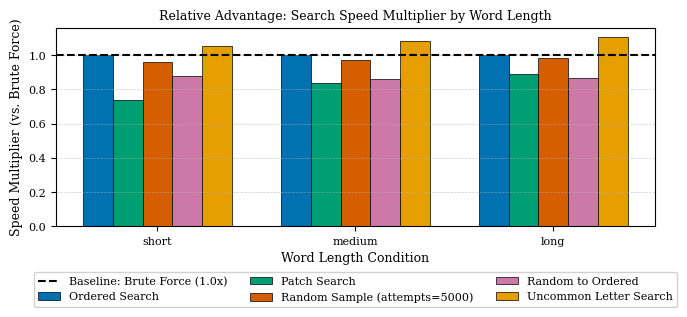

Saved figB_relative_advantage_bruteforce.pdf


In [17]:
# --- IEEE 2-column publication plot: Relative Efficiency Multiplier (vs Brute Force) ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
import os

matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'lines.linewidth':   1.8,
    'lines.markersize':  4,
    'axes.linewidth':    0.8,
    'grid.linewidth':    0.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    # 'text.usetex':     True,   # uncomment if LaTeX is installed
})
IEEE_2COL = 7.16

# We omit Brute Force from this dictionary because it will be our horizontal baseline
COLORS = {
    'Ordered Search':                '#0072B2',
    'Patch Search':                  '#009E73',
    'Random Sample (attempts=5000)': '#D55E00',
    'Random to Ordered':             '#CC79A7',
    'Uncommon Letter Search':        '#E69F00',
}
condition_order = ['short', 'medium', 'long']

# 1. Aggregate means
eff = df.groupby(['strategy', 'condition']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean'),
    size=('size', 'mean')
).reset_index()

# Calculate the metric (fraction of grid scanned per word)
eff['fraction_per_word'] = (eff['cells_examined'] / eff['total_words']) / (eff['size'] ** 2)

# 2. Pivot to easily compare against the Brute Force baseline
pivot_eff = eff.pivot(index='condition', columns='strategy', values='fraction_per_word').reindex(condition_order)

# 3. Calculate multiplier: (Brute Force Efficiency) / (Strategy Efficiency)
# A value of 2.0 means the strategy examined half as many cells as Brute Force (i.e., it is 2x faster).
multiplier_df = pivot_eff.apply(lambda col: pivot_eff['Brute Force'] / col)

os.makedirs('../plots', exist_ok=True)
fig, ax = plt.subplots(figsize=(IEEE_2COL, 3.2))

strategies_to_plot = sorted(COLORS.keys())
x = np.arange(len(condition_order))
width = 0.15 # Width of the bars
offsets = np.linspace(-width*2, width*2, len(strategies_to_plot))

# Plot bars for each strategy (excluding baseline)
for i, strategy in enumerate(strategies_to_plot):
    ax.bar(x + offsets[i], multiplier_df[strategy], width, label=strategy, 
           color=COLORS[strategy], edgecolor='black', linewidth=0.5)

# Add baseline reference line for Brute Force
ax.axhline(1.0, color='#000000', linestyle='--', linewidth=1.5, label='Baseline: Brute Force (1.0x)')

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Speed Multiplier (vs. Brute Force)')
ax.set_title('Relative Advantage: Search Speed Multiplier by Word Length')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Legend formatting
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.2), framealpha=0.9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28) # Extra space for the 3-column legend
plt.savefig('../plots/figB_relative_advantage_bruteforce.pdf')
plt.show()
print("Saved figB_relative_advantage_bruteforce.pdf")